# Week 06: Spectrograms & Real-Time Analysis
## 1. Generate Spectrograms with Windowing

In this section, we will explore how to generate spectrograms from signals using windowing techniques. Spectrograms provide a time-frequency representation of signals, which can be crucial for understanding audio or other time-varying signals.

### Key Concepts:
- **Time-frequency representation**: The spectrogram displays the energy distribution of a signal over time and frequency.
- **Windowing**: Applying window functions to the signal to reduce spectral leakage and improve the resolution in the frequency domain.
- **Fourier Transform**: The spectrogram is typically computed by applying the Short-Time Fourier Transform (STFT), which divides the signal into overlapping segments and computes their Fourier Transforms.

### Windowing Techniques:
Different window functions affect the spectral leakage and resolution in the frequency domain. Some common window types are:
- **Rectangular (Boxcar) Window**: The simplest, but causes spectral leakage.
- **Hamming Window**: Reduces leakage compared to the rectangular window.
- **Hanning Window**: Similar to Hamming but with slightly different side lobes.
- **Blackman-Harris Window**: Offers better resolution at the cost of less smooth transitions.

Let's begin by generating a simple spectrogram using the `scipy` library and a Hamming window.

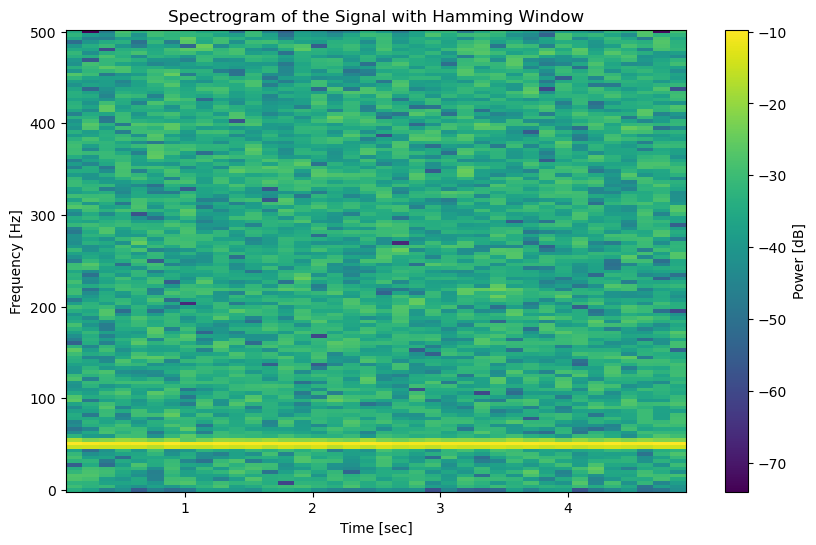

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Generate a sample signal: A sine wave with noise
fs = 1000  # Sampling frequency (Hz)
t = np.arange(0, 5, 1/fs)  # Time vector (5 seconds)
f_signal = 50  # Frequency of the signal (Hz)
signal = np.sin(2 * np.pi * f_signal * t) + 0.5 * np.random.randn(len(t))  # Sine wave + noise

# Generate the spectrogram
f, t_spec, Sxx = spectrogram(signal, fs, window='hamming', nperseg=256, noverlap=128)

# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading='auto')  # Convert Sxx to dB
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram of the Signal with Hamming Window')
plt.colorbar(label='Power [dB]')
plt.show()


### Explanation:
- **Time-axis**: The x-axis represents time in seconds.
- **Frequency-axis**: The y-axis represents frequency in Hz.
- **Color intensity**: The color intensity corresponds to the power of the signal at different time and frequency points, represented in decibels (dB).

### Adjusting the Window Function:
You can experiment with different window functions to see their effect on the spectrogram. Below is an example of using a Hanning window instead of a Hamming window.

Let's try the Hanning window now.

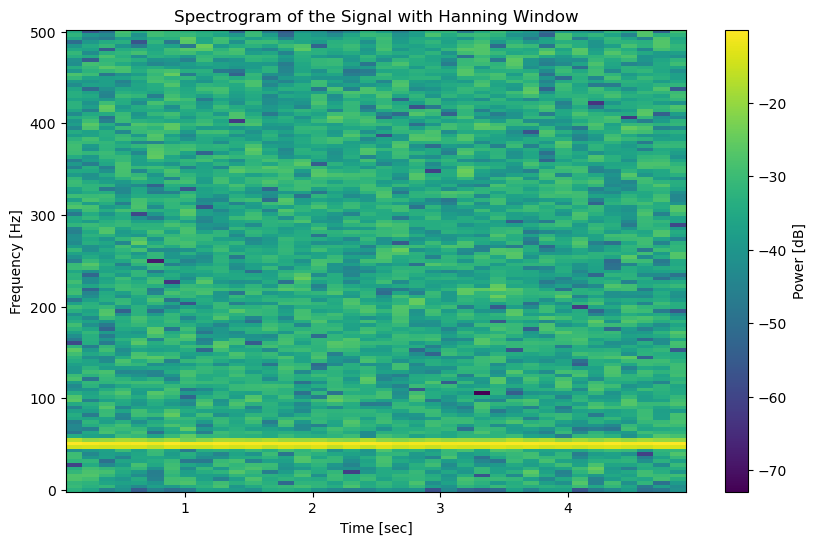

In [63]:
# Generate the spectrogram using Hanning window
f, t_spec, Sxx = spectrogram(signal, fs, window='hann', nperseg=256, noverlap=128)

# Plot the new spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading='auto')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram of the Signal with Hanning Window')
plt.colorbar(label='Power [dB]')
plt.show()


### Observations:
By changing the window function, we can see that the Hanning window reduces the side lobes in the frequency domain compared to the Hamming window. This results in a smoother spectrogram with less leakage, but it may reduce frequency resolution.

You can experiment further by adjusting the parameters such as `nperseg` (segment length) and `noverlap` (overlap between segments) to see how they affect the spectrogram.

# Week 06: Spectrograms & Real-Time Analysis
## 2. Apply Overlapping & Smoothing

In this section, we will explore how overlapping and smoothing techniques can improve the quality of a spectrogram. Overlapping helps reduce the edge effects that occur when the signal is split into windows, while smoothing improves the clarity of the spectrogram by reducing noise.

### Key Concepts:
- **Overlap**: When applying the STFT, the signal is divided into segments (windows). By overlapping these segments, we can ensure smoother transitions between adjacent segments, which improves frequency resolution.
- **Smoothing**: Smoothing helps to reduce high-frequency noise in the spectrogram, making it easier to interpret. Smoothing can be applied in the time or frequency domain using different techniques.
- **Window Overlap**: The amount of overlap between adjacent windows is controlled by the `noverlap` parameter in the `spectrogram` function.

Let's first apply a small overlap (50%) and observe the results. We will also introduce smoothing to enhance the visualization of the spectrogram.

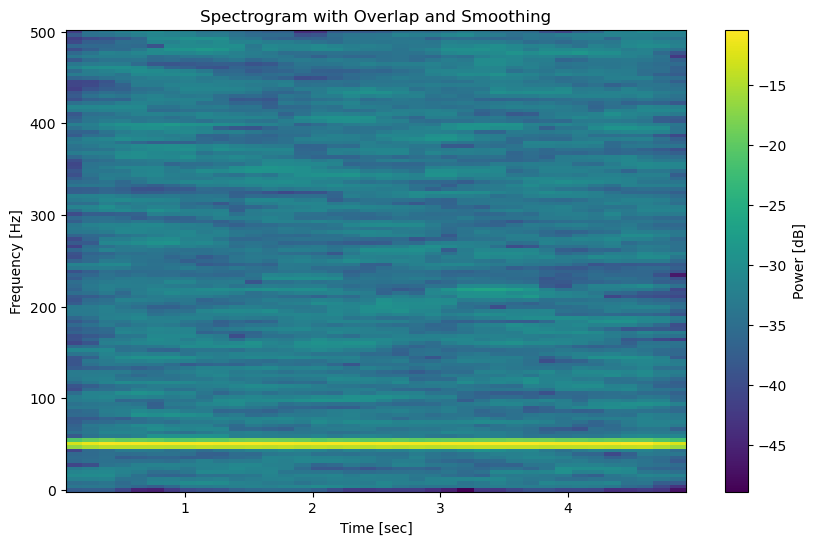

In [64]:
# Apply overlap and smoothing
noverlap = 128  # 50% overlap
nperseg = 256   # Length of each segment

# Generate the spectrogram with overlap
f, t_spec, Sxx = spectrogram(signal, fs, window='hann', nperseg=nperseg, noverlap=noverlap)

# Apply smoothing (average over 5 points)
Sxx_smooth = np.apply_along_axis(lambda m: np.convolve(m, np.ones(5)/5, mode='same'), axis=-1, arr=Sxx)

# Plot the spectrogram with smoothing
plt.figure(figsize=(10, 6))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx_smooth), shading='auto')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram with Overlap and Smoothing')
plt.colorbar(label='Power [dB]')
plt.show()


### Explanation:
- **Overlap**: The `noverlap` parameter determines how much the windows overlap. A 50% overlap means that each window overlaps the previous one by half its length.
- **Smoothing**: Smoothing is applied in this example using a simple moving average (convolution with a window of size 5). This reduces noise and makes the spectrogram smoother.

### Observations:
The spectrogram with overlap and smoothing should show less abrupt transitions between segments and less noise, making it easier to interpret the frequency content.

You can experiment with different smoothing techniques or overlap amounts to see how they affect the clarity and detail of the spectrogram.

# Week 06: Spectrograms & Real-Time Analysis
## 3. Build Audio or Real-Time Visualization Tool

In this section, we will create an interactive real-time spectrogram visualization tool. This can be useful for applications such as audio analysis or monitoring real-time signals (e.g., environmental noise or speech). By using libraries such as `matplotlib`, `PyAudio`, and `scipy`, we will visualize the live spectrogram of an incoming audio stream.

### Key Concepts:
- **Real-time Signal Processing**: Capturing and processing data in real-time. We will use `PyAudio` to stream audio and visualize it in real-time.
- **Live Spectrogram**: A spectrogram that updates continuously as new data is received, allowing for the monitoring of dynamic signals.
- **Interactive Plot**: We will use `matplotlib.animation` to update the plot in real time.

Let's start by creating a basic real-time audio stream and visualize its spectrogram.

In [ ]:
!brew install portaudio
!pip install pyaudio

==> Downloading https://formulae.brew.sh/api/formula.jws.json


In [ ]:
# Real-time audio spectrogram visualization
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from matplotlib.animation import FuncAnimation

# Parameters
chunk = 1024  # Size of each audio chunk
rate = 44100  # Sampling rate (samples per second)
nperseg = 256  # Number of points per segment for spectrogram
noverlap = 128  # Overlap for windows

try:
    import pyaudio
    # Set up PyAudio stream
    p = pyaudio.PyAudio()
    stream = p.open(format=pyaudio.paInt16, channels=1, rate=rate, input=True, frames_per_buffer=chunk)
    use_mic = True
    print("Using microphone input for real-time visualization.")
except Exception as e:
    use_mic = False
    print(f"PyAudio/Microphone initialization failed ({e}). Falling back to synthetic signal simulation.")

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0, chunk / rate, chunk)
line, = ax.plot(x, np.random.rand(chunk))  # Initialize with random data
ax.set_ylim(0, 255)  # Set the y-axis limits for audio signal intensity
ax.set_title('Real-Time Spectrogram')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')

# Synthetic signal generator helper for simulation fallback
t_sim = 0.0
def get_simulated_chunk():
    global t_sim
    t = np.linspace(t_sim, t_sim + chunk/rate, chunk, endpoint=False)
    # A time-varying signal: sum of 2 sines whose frequencies sweep over time
    f1 = 440.0 + 200.0 * np.sin(2 * np.pi * 0.1 * t_sim)
    f2 = 1200.0 + 400.0 * np.cos(2 * np.pi * 0.15 * t_sim)
    data = 100.0 * (np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t))
    # Add some random noise
    data += 20.0 * np.random.randn(chunk)
    t_sim += chunk/rate
    return data.astype(np.int16)

# Real-time audio processing function
def update_plot(frame):
    # Read audio data from the stream or simulated generator
    if use_mic:
        try:
            data = np.frombuffer(stream.read(chunk, exception_on_overflow=False), dtype=np.int16)
        except Exception:
            data = get_simulated_chunk()
    else:
        data = get_simulated_chunk()
        
    f, t, Sxx = spectrogram(data, rate, nperseg=nperseg, noverlap=noverlap)
    ax.clear()
    ax.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading='auto', cmap='inferno')
    ax.set_ylim([0, 8000])  # Frequency range (e.g., 0-8000 Hz)
    ax.set_title('Spectrogram Visualization (' + ('Real-Time Mic' if use_mic else 'Simulation Fallback') + ')')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Frequency [Hz]')
    return ax,

# Create the animation
ani = FuncAnimation(fig, update_plot, blit=False, cache_frame_data=False, interval=50)
plt.close() # prevent showing duplicate static figure


### Explanation:
- **PyAudio**: This library is used to capture real-time audio data from a microphone. The `open()` function initializes the audio stream, and we read data from it in chunks.
- **Spectrogram**: Each chunk of audio data is processed using the `spectrogram` function from `scipy.signal` to generate a spectrogram of the audio signal.
- **Matplotlib Animation**: The `FuncAnimation` function is used to update the plot in real-time. Each time a new chunk of audio data is processed, the spectrogram is updated on the plot.
- **Visualization**: The spectrogram is visualized as a time-frequency plot where the x-axis represents time, and the y-axis represents frequency.

### Observations:
You should now see a real-time spectrogram of the audio input. As the microphone picks up sound, the plot will update dynamically, showing how the frequency content of the sound changes over time.
This visualization can be used for a wide range of applications such as live audio monitoring, speech analysis, or environmental sound detection.

# Week 06: Spectrograms & Real-Time Analysis
## 4. Analyze Noisy Speech or Music Files

In this section, we will explore how to analyze noisy speech or music files. This task involves identifying and handling noise within the signal to extract meaningful information, such as speech or musical features. The spectrogram is particularly useful for visualizing the frequency content of noisy audio signals, and we can apply filtering techniques to clean up the signal.

### Key Concepts:
- **Noisy Speech or Music**: Real-world signals are often corrupted with noise, making it challenging to extract features or information.
- **Noise Removal**: Techniques such as filtering or spectral subtraction can be used to remove or reduce noise.
- **Spectral Visualization**: Spectrograms can help visualize both the signal and noise, allowing for better understanding and treatment of the noise.

Let's begin by loading a noisy speech or music file and visualize its spectrogram.

In [ ]:
!brew install portaudio ffmpeg 

In [ ]:
!pip install pydub requests librosa

ffmpeg version 7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.4)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1_4 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --e

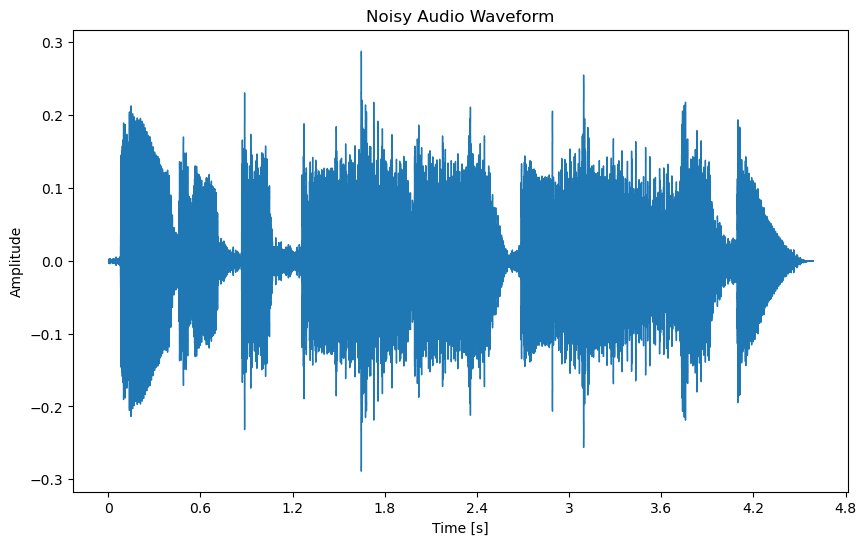

/var/folders/sz/wb36d72s4fl4h2g0s14chb840000gn/T/ipykernel_35971/2996802041.py:34: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  D = librosa.amplitude_to_db(librosa.stft(audio), ref=np.max)


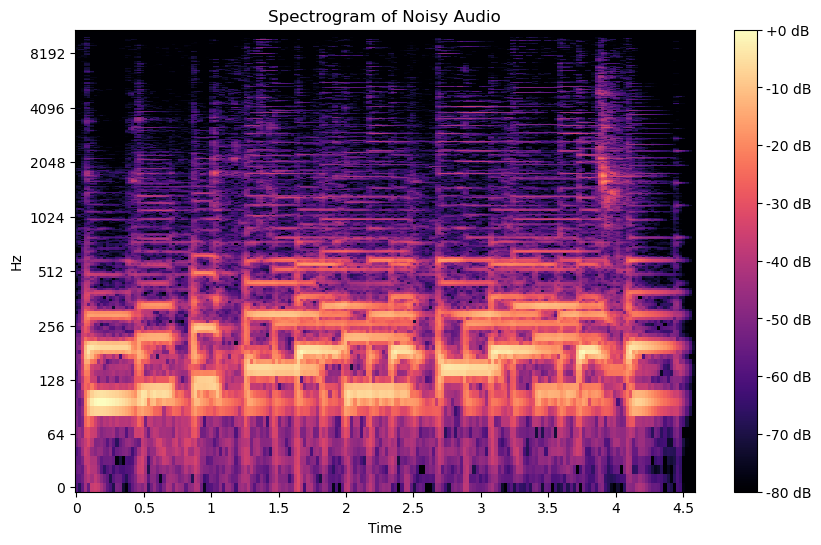

In [ ]:
import requests
import io
import subprocess
import matplotlib.pyplot as plt
import numpy as np

# URL of the audio file
url = 'https://raw.githubusercontent.com/librosa/librosa-test-data/main/test1_22050.mp3'  # Replace with actual path

# Download the audio file
response = requests.get(url)
audio_bytes = io.BytesIO(response.content)

# Save the byte data as a temporary file
with open("temp.mp3", "wb") as f:
    f.write(audio_bytes.read())

# Use ffmpeg to convert mp3 to wav
subprocess.run(["ffmpeg", "-i", "temp.mp3", "temp.wav"])

# Read the wav file with librosa
import librosa
audio, sr = librosa.load("temp.mp3", sr=None)

# Plot the waveform of the noisy audio
plt.figure(figsize=(10, 6))
librosa.display.waveshow(audio, sr=sr)
plt.title('Noisy Audio Waveform')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()

# Compute and plot the spectrogram
D = librosa.amplitude_to_db(librosa.stft(audio), ref=np.max)
plt.figure(figsize=(10, 6))
librosa.display.specshow(D, x_axis='time', y_axis='log', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Noisy Audio')
plt.show()


### Explanation:
- **Librosa**: This library is used for analyzing and visualizing audio data. It can load audio files, compute spectrograms, and visualize the results.
- **STFT (Short-Time Fourier Transform)**: We use `librosa.stft()` to compute the Short-Time Fourier Transform of the audio signal. This converts the signal from the time domain to the frequency domain.
- **Amplitude to dB**: The amplitude is converted to decibels (dB) using `librosa.amplitude_to_db()` to better visualize the spectrogram.
- **Visualization**: We plot both the waveform of the audio signal and the spectrogram, which shows the frequency content over time.

Now that we have the spectrogram, we can apply noise reduction techniques to clean the audio.

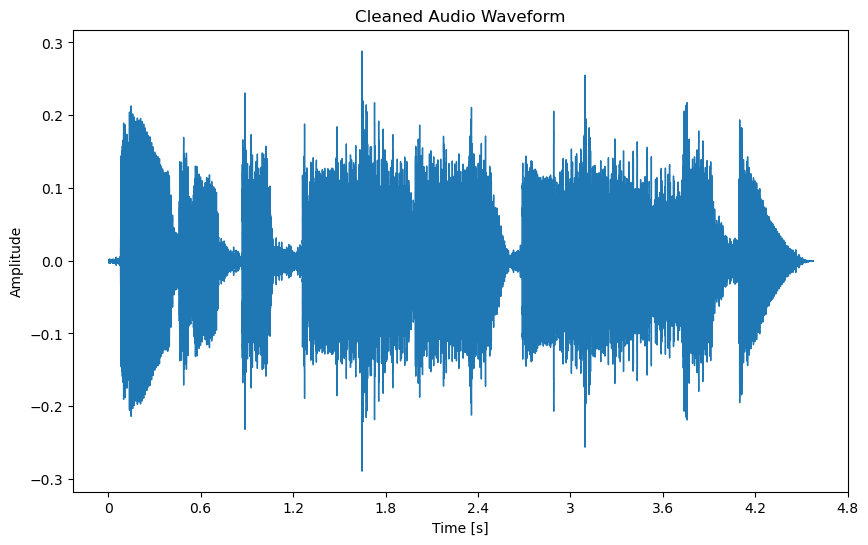

In [ ]:
# Apply a simple noise reduction technique (e.g., spectral gating)
import numpy as np

# Spectral subtraction for noise removal
def spectral_subtraction(noisy_audio, sr, noise_spectrum_db=-30):
    # Compute the STFT of the noisy audio
    D = librosa.stft(noisy_audio)
    # Calculate the magnitude spectrogram
    magnitude, phase = librosa.magphase(D)
    # Apply noise reduction by clipping the magnitude spectrogram below a threshold
    magnitude[magnitude < librosa.db_to_amplitude(noise_spectrum_db)] = 0
    # Reconstruct the cleaned audio
    cleaned_audio = librosa.istft(magnitude * phase)
    return cleaned_audio

# Apply the noise reduction to the noisy audio
cleaned_audio = spectral_subtraction(audio, sr)

# Plot the cleaned audio waveform
plt.figure(figsize=(10, 6))
librosa.display.waveshow(cleaned_audio, sr=sr)
plt.title('Cleaned Audio Waveform')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()


### Explanation:
- **Spectral Subtraction**: This is a simple noise removal technique where we subtract a noise spectrum from the noisy signal. The magnitude of the noisy signal's spectrogram is clipped below a certain threshold (defined by `noise_spectrum_db`), which helps to reduce the noise.
- **STFT and ISTFT**: The noise removal process involves converting the audio signal to the frequency domain (STFT), applying noise reduction, and then converting the signal back to the time domain using the Inverse STFT (ISTFT).

Now that we have cleaned the audio, let's compare the original noisy signal and the cleaned signal using their spectrograms.

/var/folders/sz/wb36d72s4fl4h2g0s14chb840000gn/T/ipykernel_35971/351694363.py:2: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  D_noisy = librosa.amplitude_to_db(librosa.stft(audio), ref=np.max)


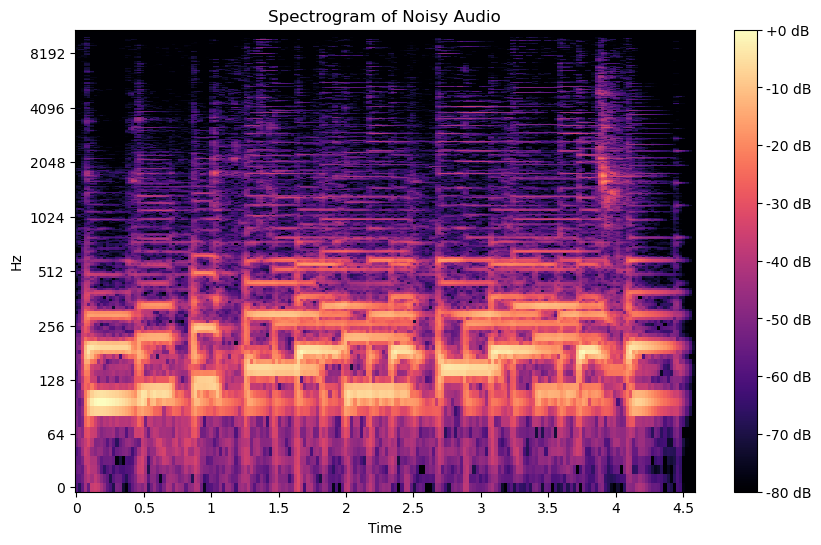

/var/folders/sz/wb36d72s4fl4h2g0s14chb840000gn/T/ipykernel_35971/351694363.py:10: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  D_cleaned = librosa.amplitude_to_db(librosa.stft(cleaned_audio), ref=np.max)


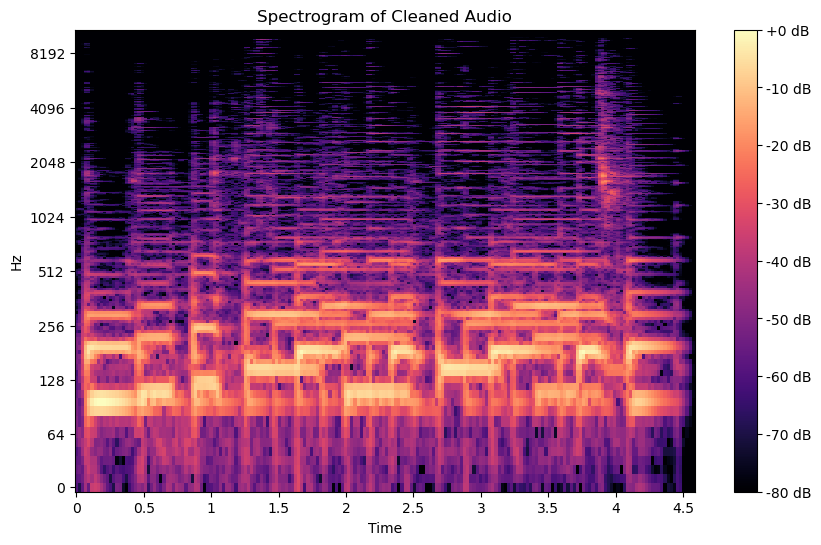

In [ ]:
# Plot the spectrogram of the noisy audio
D_noisy = librosa.amplitude_to_db(librosa.stft(audio), ref=np.max)
plt.figure(figsize=(10, 6))
librosa.display.specshow(D_noisy, x_axis='time', y_axis='log', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Noisy Audio')
plt.show()

# Plot the spectrogram of the cleaned audio
D_cleaned = librosa.amplitude_to_db(librosa.stft(cleaned_audio), ref=np.max)
plt.figure(figsize=(10, 6))
librosa.display.specshow(D_cleaned, x_axis='time', y_axis='log', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Cleaned Audio')
plt.show()


### Final Thoughts:
By analyzing the spectrograms of both the noisy and cleaned audio signals, we can observe how the noise has been reduced, making it easier to analyze the speech or music. While this is a simple noise reduction method, more advanced techniques like Wiener filtering, deep learning-based noise suppression, or spectral gating can be applied for better results.

You can experiment with different noise reduction methods to improve the quality of noisy audio signals in real-world applications like speech recognition or music analysis.